Saved top-20 CpGs -> outputs/top20_variable_cpgs.csv

=== Training & Evaluation ===
Logistic Regression           CV AUROC: 0.7369   Test AUROC: 0.7816
Random Forest                 CV AUROC: 0.6834   Test AUROC: 0.6849
Gradient Boosting             CV AUROC: 0.7163   Test AUROC: 0.5966
SVM (RBF, top-500)            CV AUROC: 0.6450   Test AUROC: 0.6176
XGBoost (top-500)             CV AUROC: 0.5602   Test AUROC: 0.6541

--- Sorted Results (by Test AUROC) ---
              Model  Train AUROC (CV mean)  Test AUROC (Adult)
Logistic Regression               0.736909            0.781603
      Random Forest               0.683434            0.684895
  XGBoost (top-500)               0.560246            0.654093
 SVM (RBF, top-500)               0.644998            0.617553
  Gradient Boosting               0.716348            0.596624

Saved results -> outputs/model_auroc_results.csv


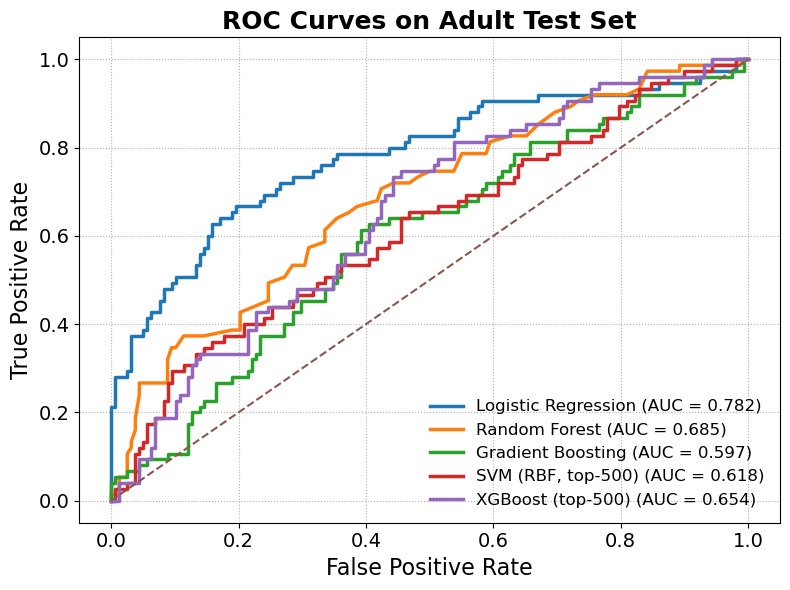

Saved publication-quality ROC plot -> outputs/roc_curves_adult_test_pubquality.png


In [3]:
"""
ART vs non-ART classification on CpG methylation

- Train on neonate samples
- Test on adult samples
- Models: Logistic Regression, Random Forest, Gradient Boosting, SVM (RBF), XGBoost
- AUROC used for evaluation
- SVM & XGBoost use top-500 most variable CpGs (from training) to reduce compute

Outputs:
- Prints CV AUROC (neonate) and Test AUROC (adult)
- Saves: results CSV, top-500 CpG list, and ROC curve PNG

Dependencies:
    pip install pandas numpy scikit-learn matplotlib xgboost
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("Warning: xgboost not found; XGBoost model will be skipped.")

# ----------------------------- Config -----------------------------
CSV_PATH = "control_probes_ART_nonART_data.csv"  # <- update path if needed
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 10
CV_FOLDS = 5
TOPK = 20

# ----------------------------- Load ------------------------------
df = pd.read_csv(CSV_PATH)

assert "Donor_time" in df.columns and "Donor_status" in df.columns, \
    "Expected columns 'Donor_time' and 'Donor_status' not found."

# Split by time
train_df = df[df["Donor_time"] == "neonate"].copy()
test_df  = df[df["Donor_time"] == "adult"].copy()

# Features/target
drop_cols = ["Donor_time", "Donor_status", "Donor_ID"]
X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Donor_status"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Donor_status"]

# Encode target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# --------------------- Top-k variance selection ------------------
# Use training data only
variances = X_train.var(axis=0, ddof=0)
topk_features = variances.sort_values(ascending=False).head(TOPK).index.tolist()

# Save top-k CpGs
topk_path = os.path.join(OUTPUT_DIR, f"top{TOPK}_variable_cpgs.csv")
pd.Series(topk_features, name="CpG_ID").to_csv(topk_path, index=False)
print(f"Saved top-{TOPK} CpGs -> {topk_path}")

# A column selector using ColumnTransformer (clone-safe)
def topk_selector():
    # Keep as names; ColumnTransformer handles pandas column names
    return ColumnTransformer(
        transformers=[("sel", "passthrough", topk_features)],
        remainder="drop",
        verbose_feature_names_out=False
    )

# --------------------------- Pipelines ---------------------------
pipelines = {}

# Logistic Regression (all features, scaled)
pipelines["Logistic Regression"] = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(
        penalty="l2", solver="saga", max_iter=5000, random_state=RANDOM_STATE
    ))
])

# Random Forest (all features)
pipelines["Random Forest"] = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=500, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1
    ))
])

# Gradient Boosting (all features)
pipelines["Gradient Boosting"] = Pipeline([
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

# SVM (RBF) uses top-500 + scaling
pipelines["SVM (RBF, top-500)"] = Pipeline([
    ("select", topk_selector()),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

# XGBoost (top-500)
if HAS_XGB:
    pipelines["XGBoost (top-500)"] = Pipeline([
        ("select", topk_selector()),
        ("clf", XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

# ---------------------- Train / Evaluate -------------------------
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rows = []
fitted = {}

print("\n=== Training & Evaluation ===")
for name, pipe in pipelines.items():
    # CV AUROC on neonate (train)
    cv_auc = cross_val_score(
        pipe, X_train, y_train_enc, cv=cv, scoring="roc_auc", n_jobs=-1
    ).mean()

    # Fit on full neonate set
    pipe.fit(X_train, y_train_enc)
    fitted[name] = pipe

    # Evaluate on adult set
    y_prob = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test_enc, y_prob)

    rows.append((name, cv_auc, test_auc))
    print(f"{name:28s}  CV AUROC: {cv_auc:.4f}   Test AUROC: {test_auc:.4f}")

# Results table
results_df = pd.DataFrame(rows, columns=["Model", "Train AUROC (CV mean)", "Test AUROC (Adult)"])
results_df = results_df.sort_values(by="Test AUROC (Adult)", ascending=False).reset_index(drop=True)
print("\n--- Sorted Results (by Test AUROC) ---")
print(results_df.to_string(index=False))

# Save results
results_path = os.path.join(OUTPUT_DIR, "model_auroc_results.csv")
results_df.to_csv(results_path, index=False)
print(f"\nSaved results -> {results_path}")

# --------------------------- ROC Curves (Publication Quality) --------------------------
plt.figure(figsize=(8, 6))

# Plot ROC for each model
for name, pipe in fitted.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_enc, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC = {roc_auc:.3f})",
        linewidth=2.5  # thicker lines
    )

# Plot diagonal line for random chance
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5)

# Titles and labels (larger font)
plt.title("ROC Curves on Adult Test Set", fontsize=18, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)

# Ticks and legend
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, loc="lower right", frameon=False)

# Add grid and tight layout for clean look
plt.grid(True, linestyle=":", linewidth=0.8)
plt.tight_layout()

# Save and show
roc_path = os.path.join(OUTPUT_DIR, "roc_curves_adult_test_pubquality.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved publication-quality ROC plot -> {roc_path}")

In [7]:
import pandas as pd

df = pd.read_csv("corsiv_probes_ART_nonART_data.csv")

# Count by time and status
counts = df.groupby(["Donor_time", "Donor_status"]).size().reset_index(name="n")
print(counts)

# Optional sanity check: are there any donors with both ART and non-ART labels?
ambiguous = (
    df.groupby("Donor_ID")["Donor_status"]
    .nunique()
    .reset_index(name="n_statuses")
)
print("Donors with >1 status label:", ambiguous[ambiguous["n_statuses"] > 1])

  Donor_time Donor_status   n
0      adult          ART  54
1      adult      non-ART  75
2    neonate          ART  79
3    neonate      non-ART  58
Donors with >1 status label:      Donor_ID  n_statuses
127  Donor_71           2
128  Donor_72           2
129  Donor_73           2
130  Donor_74           2
131  Donor_75           2
132  Donor_76           2
133  Donor_77           2
134  Donor_78           2


In [9]:
# safer collapse that checks consistency
agg_features = df.groupby(["Donor_ID", "Donor_time"])[feature_cols].mean()
status_check = df.groupby(["Donor_ID", "Donor_time"])["Donor_status"].nunique()

if (status_check > 1).any():
    print("Warning: Some Donor_ID + Donor_time combinations have multiple statuses!")
    print(status_check[status_check > 1])

# take the mode (most frequent status) instead of .first()
labels = (
    df.groupby(["Donor_ID", "Donor_time"])["Donor_status"]
    .agg(lambda x: x.mode().iat[0])
)

NameError: name 'feature_cols' is not defined

In [ ]:
Residualize methylation values.
Before classification, regress each CpG’s β-values on the estimated cell proportions (and possibly other covariates like age, sex, batch), and use the residuals as inputs to your classifier.
This effectively removes linear effects of cell composition from methylation levels.